In [1]:
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from math import ceil
from scipy.stats import ttest_ind, ks_2samp

# Opt-in to the future behavior to silence the warning
pd.set_option('future.no_silent_downcasting', True)

# Loading dataset 
interim = Path("data/interim")
interim.mkdir(parents=True, exist_ok=True)
data_path = "../data/diabetes.csv"
fhgd = pd.read_csv(data_path)

# Quick checks
print("Shape:", fhgd.shape)
print("Columns:", fhgd.columns.tolist())

Shape: (2000, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [2]:
fhgd.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [3]:
# Preview Data Types and Non-Null Counts
fhgd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [4]:
# Summary Statistics (Central Tendency & Spread)
fhgd.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [5]:
fhgd.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
# List of biological features where '0' indicates missing data (impossible in reality)
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Create a boolean mask for zeros, sum the True values, and format as a DataFrame
zero_counts = (fhgd[zero_cols] == 0).sum().to_frame("zero_count")

# Render the table to inspect the count of hidden missing values
display(zero_counts)

,zero_count
Glucose,13
BloodPressure,90
SkinThickness,573
Insulin,956
BMI,28


In [7]:
# Create a working copy to preserve the original raw data structure
clean = fhgd.copy()

# Replace 0s with NaN in the identified biological columns to formally mark them as missing
clean[zero_cols] = clean[zero_cols].replace(0, pd.NA)

# Save the intermediate dataset to the interim directory
out_path = interim / "fhgd_step1_clean.csv"
clean.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: data\interim\fhgd_step1_clean.csv


In [8]:
# Reload the clean dataset 
clean = pd.read_csv(interim / "fhgd_step1_clean.csv")
print("Shape:", clean.shape)
print("Missing values before handling:\n", clean.isnull().sum())

Shape: (2000, 9)
Missing values before handling:
 Pregnancies                   0
Glucose                      13
BloodPressure                90
SkinThickness               573
Insulin                     956
BMI                          28
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
# Add missingness indicator columns
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_zero:
    # Generate binary flags (0/1) to capture the pattern of missingness as a predictive signal
    clean[f"{col}_is_missing"] = clean[col].isna().astype(int)

# Median imputation
imputed = clean.copy()
# Fill NaNs with the median to create a complete dataset; chosen for robustness against skew/outliers
imputed[cols_with_zero] = imputed[cols_with_zero].fillna(imputed[cols_with_zero].median())

# Audit the final dataframe to confirm no missing values remain
print("\nMissing values after imputation:\n", imputed.isnull().sum())

# Save the imputed artifact (Step 2) strictly for EDA and visualization purposes
out_path = interim / "fhgd_step2_imputed.csv"
imputed.to_csv(out_path, index=False)
print("Saved:", out_path)


Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_is_missing          0
BloodPressure_is_missing    0
SkinThickness_is_missing    0
Insulin_is_missing          0
BMI_is_missing              0
dtype: int64
Saved: data\interim\fhgd_step2_imputed.csv


In [10]:
imputed.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_is_missing,BloodPressure_is_missing,SkinThickness_is_missing,Insulin_is_missing,BMI_is_missing
0,2,138.0,62.0,35.0,126.0,33.6,0.127,47,1,0,0,0,1,0
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0,0,0,0,0,0
2,0,145.0,72.0,29.0,126.0,44.2,0.630,31,1,0,1,1,1,0
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1,0,0,0,0,0
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0,0,0,0,0,0


In [11]:
# Define the project root directory
PROJECT = Path(".")
# Create a 'drafts' directory to store all experimental runs; create parents if missing
DRAFTS = PROJECT/"reports"/"drafts"; DRAFTS.mkdir(parents=True, exist_ok=True)

# name each run once per session to distinguish experiments
RUN_TAG = "eda-fhgd"  # change per notebook/task: e.g., "iforest-grid", "ocsvm-baseline"

# Create a unique, timestamped directory for this specific run to avoid overwriting previous results
RUN_DIR = DRAFTS / f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{RUN_TAG}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Create sub-directories for organizing figures and tables within this run
FIGS = RUN_DIR / "figs"; FIGS.mkdir(exist_ok=True)
TABLES = RUN_DIR / "tables"; TABLES.mkdir(exist_ok=True)

# Helper function to save matplotlib figures to the run's 'figs' folder
def save_fig(name):  # no extensions in name
    import matplotlib.pyplot as plt
    # Construct the full path
    p = FIGS / f"{name}.png"
    # Save with high DPI and tight bounding box for report-ready quality
    plt.savefig(p, dpi=150, bbox_inches="tight")
    print("saved fig ->", p)

# Helper function to save pandas DataFrames to the run's 'tables' folder
def save_table(df, name):
    # Construct the full path with .csv extension
    p = TABLES / f"{name}.csv"
    # Save without the index to keep the CSV clean
    df.to_csv(p, index=False)
    print("saved table ->", p)

In [12]:
# paths
IMPUTED_PATH = Path("data/interim/fhgd_step2_imputed.csv")
imputed = pd.read_csv(IMPUTED_PATH)

# select numeric features (exclude Outcome and *_is_missing flags)
all_num = imputed.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in all_num if c != "Outcome" and not c.endswith("_is_missing")]

print("Features to profile:", feature_cols)

# compact summary table (rounded for readability)
summary = imputed[feature_cols].agg(["count","mean","std","min","max","skew"]).T.round(3)
summary = summary.rename_axis("feature").reset_index()

display(summary)

# (optional) save the table to drafts

print("Saved -> reports/tables/univariate_summary_fhgd.csv")

Features to profile: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,feature,count,mean,std,min,max,skew
0,Pregnancies,2000.0,3.704,3.306,0.000,17.00,0.982
1,Glucose,2000.0,121.943,30.536,44.000,199.00,0.516
2,BloodPressure,2000.0,72.386,11.950,24.000,122.00,0.220
3,SkinThickness,2000.0,29.244,9.125,7.000,110.00,1.312
4,Insulin,2000.0,140.482,81.563,14.000,744.00,2.976
5,BMI,2000.0,32.647,7.190,18.200,80.60,0.937
6,DiabetesPedigreeFunction,2000.0,0.471,0.324,0.078,2.42,1.812
7,Age,2000.0,33.090,11.786,21.000,81.00,1.181


Saved -> reports/tables/univariate_summary_fhgd.csv


saved fig -> reports\drafts\20260206_113409_eda-fhgd\figs\univariate_panels_fhgd.png
Saved -> reports/figures/univariate_panels_fhgd.png


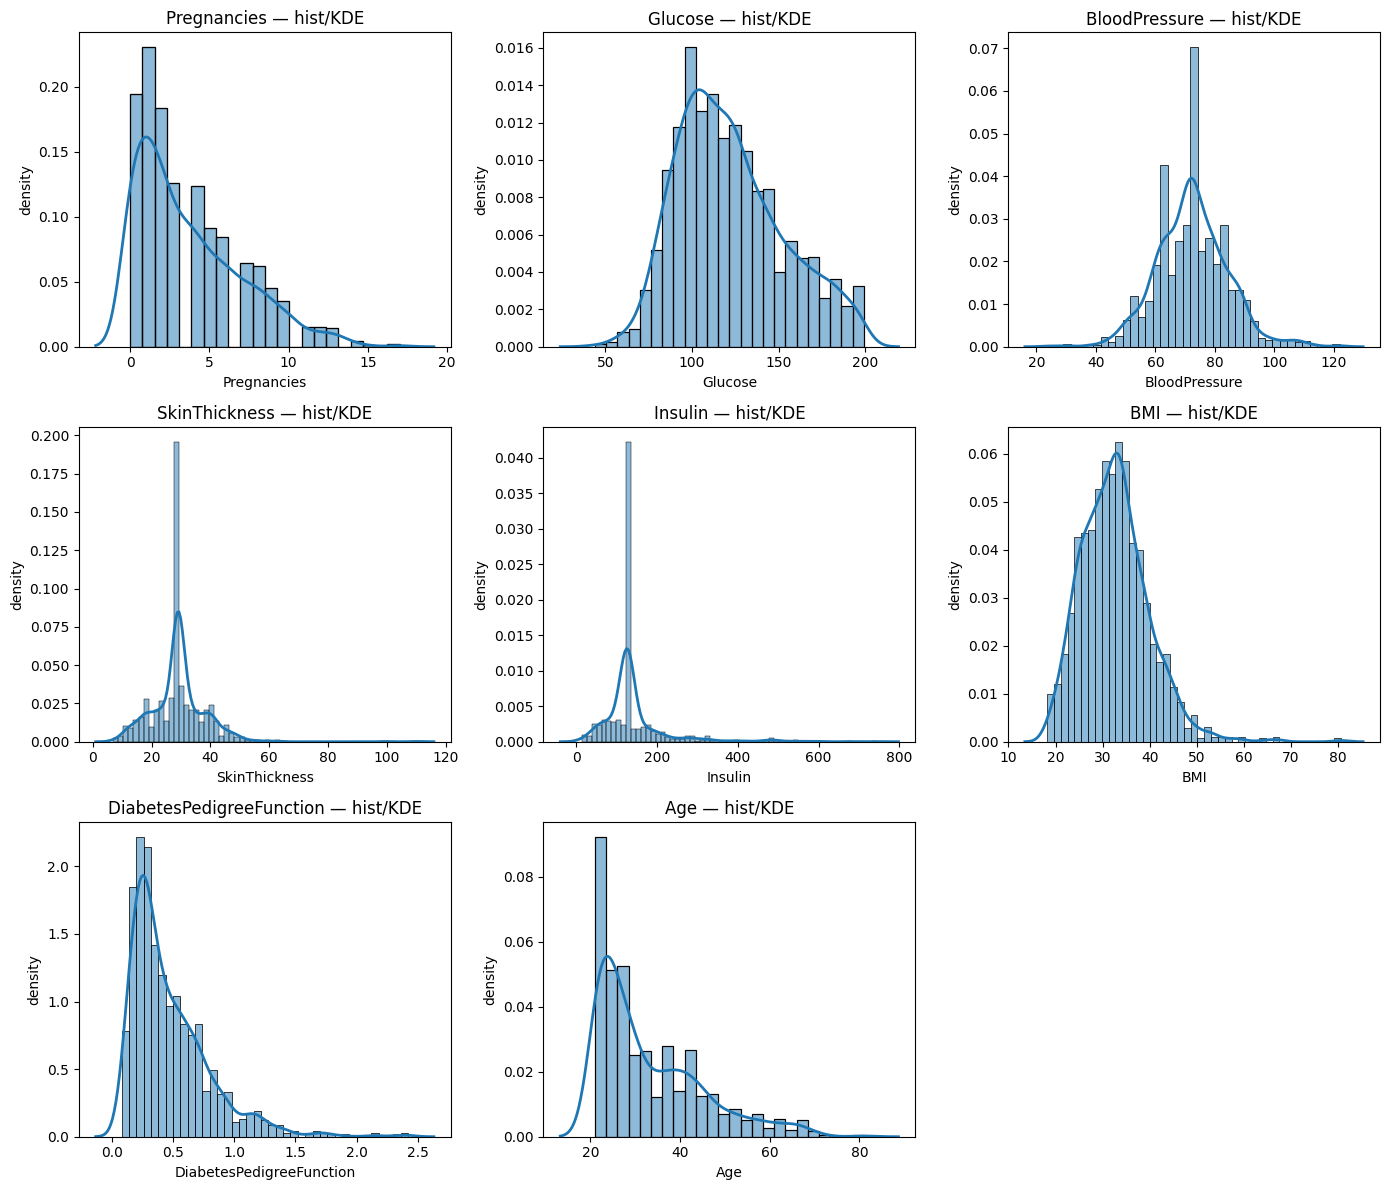

In [13]:
# Helper: Freedman-Diaconis rule for adaptive binning
def fd_bins(x):
    x = np.asarray(x.dropna())
    if x.size < 2:
        return 10  # Fallback for empty/single-value features
    
    # Calculate Interquartile Range (IQR) = 75th percentile - 25th percentile
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    
    # If variance is zero (all values are the same), return default to avoid division by zero
    if iqr == 0:
        return 10
    
    # The FD Formula: h = 2 * IQR * n^(-1/3)
    h = 2 * iqr * (x.size ** (-1/3))
    
    # Calculate bin count: Range / Bin_Width
    # Clip between 10 and 60 to keep plots readable (prevents 1000+ tiny bins)
    bins = int(np.clip(np.ceil((x.max() - x.min()) / h), 10, 60))
    return bins

# Plotting Setup: Create a dynamic grid (3 columns) based on feature count
n = len(feature_cols)
ncols = 3
nrows = ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.ravel()  # Flatten the 2D grid into a 1D array for easy iteration

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = imputed[col].dropna()
    
    # Dynamically calculate bins for this specific feature
    bins = fd_bins(data)

    # Plot Histogram: Use 'stat="density"' so the area sums to 1 (matching the KDE scale)
    sns.histplot(data, bins=bins, stat="density", alpha=0.5, ax=ax)
    
    # Plot KDE: The smooth probability density curve $P(X)$ overlay
    sns.kdeplot(data, ax=ax, lw=2)

    ax.set_title(f"{col} — hist/KDE")
    ax.set_xlabel(col)
    ax.set_ylabel("density")

# Cleanup: Hide any empty subplots if the number of features isn't a multiple of 3
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

# Save the artifact for the report
save_fig("univariate_panels_fhgd")
print("Saved -> reports/figures/univariate_panels_fhgd.png")

plt.show()

Baseline Class Proportion:
Outcome
0    0.658
1    0.342
Name: proportion, dtype: float64
saved fig -> reports\drafts\20260206_113409_eda-fhgd\figs\class_balance_fhgd.png


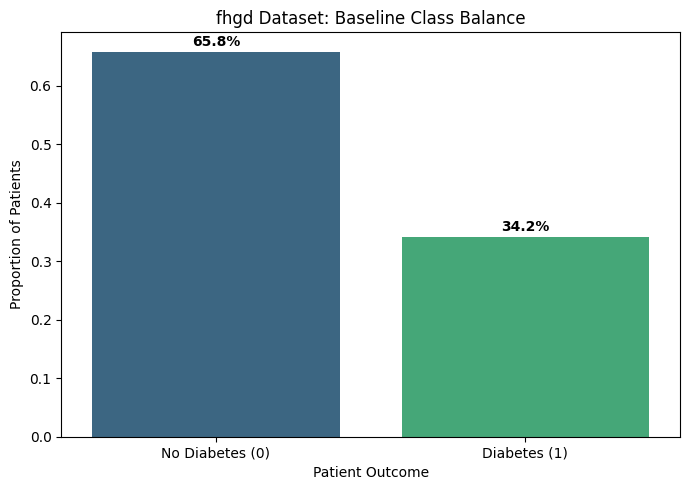

In [14]:
# Calculate and Print Class Balance
print("Baseline Class Proportion:")
class_balance = imputed['Outcome'].value_counts(normalize=True)
print(class_balance)

# Visualize the Class Balance (Warning-Free) 
fig, ax = plt.subplots(figsize=(7, 5))

# Modified the barplot call to prevent the FutureWarning
# Assigning 'x' to 'hue' and disabling the legend is the recommended practice
sns.barplot(x=class_balance.index, y=class_balance.values, ax=ax, palette='viridis',
            hue=class_balance.index, legend=False)

# Add plot titles and labels for clarity
ax.set_title('fhgd Dataset: Baseline Class Balance')
ax.set_ylabel('Proportion of Patients')
ax.set_xlabel('Patient Outcome')

# Modified the tick label setting to prevent the UserWarning
# Explicitly set the ticks before setting their labels
ax.set_xticks(class_balance.index)
ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])

# Add percentage labels to the bars for easy interpretation
for index, value in enumerate(class_balance):
    ax.text(index, value + 0.01, f'{value:.1%}', ha='center', fontweight='bold')

plt.tight_layout()

# --- Save the Figure Using Your Helper Function ---
save_fig("class_balance_fhgd")

plt.show()

saved fig -> reports\drafts\20260206_113409_eda-fhgd\figs\correlation_heatmap_fhgd.png


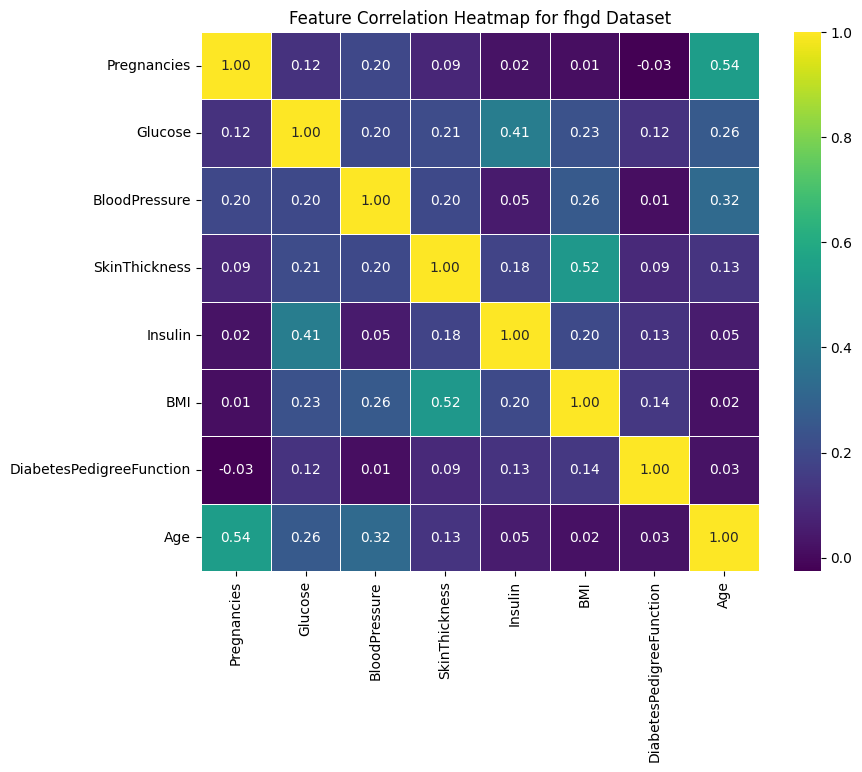

In [15]:
# Calculate the correlation matrix for the numerical features.
corr_matrix = imputed[feature_cols].corr()

# Set up the matplotlib figure.
plt.figure(figsize=(9, 7))

# Draw the heatmap with the mask and correct aspect ratio.
sns.heatmap(corr_matrix, 
            annot=True,      # Write the data value in each cell
            fmt=".2f",       # Use two decimal places for annotations
            cmap='viridis',    # Use a visually appealing color map
            linewidths=.5)   # Add lines between cells

# Add a descriptive title.
plt.title('Feature Correlation Heatmap for fhgd Dataset')

# Save the figure to the run-specific directory.
save_fig("correlation_heatmap_fhgd")

# Display the plot.
plt.show()

saved fig -> reports\drafts\20260206_113409_eda-fhgd\figs\boxplots_by_outcome_fhgd.png


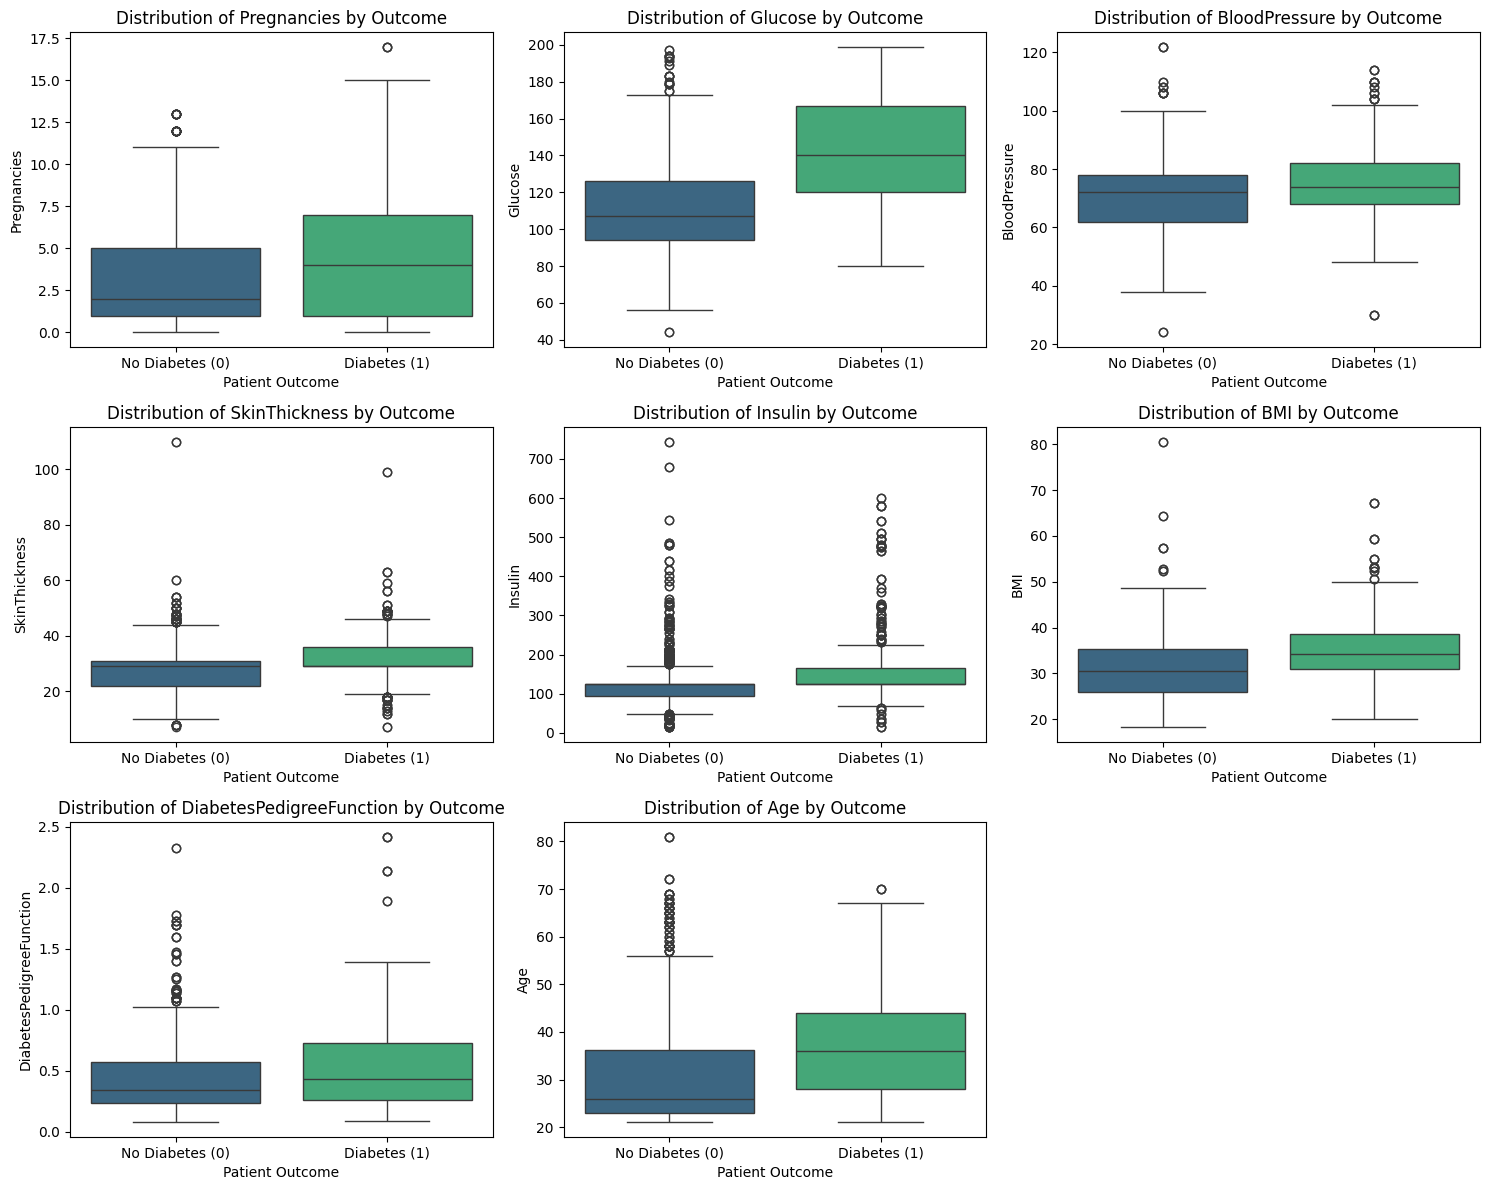

In [16]:
# Set up the plotting grid
n_features = len(feature_cols)
ncols = 3
nrows = ceil(n_features / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.ravel() 

# Create a box plot for each feature by Outcome 
for i, col in enumerate(feature_cols):
    ax = axes[i]
    
    # Modified the boxplot call to prevent the FutureWarning
    sns.boxplot(data=imputed, x='Outcome', y=col, ax=ax, palette='viridis',
                hue='Outcome', legend=False)
    
    # Add plot titles and labels
    ax.set_title(f'Distribution of {col} by Outcome')
    ax.set_xlabel('Patient Outcome')
    ax.set_ylabel(col)

    # Modified the tick label setting to prevent the UserWarning
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])

# Hide any unused subplots in the grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# --- Save the Figure Using Your Helper Function ---
save_fig("boxplots_by_outcome_fhgd")

plt.show()

In [17]:
# Calculate descriptive statistics for each feature, grouped by the 'Outcome' variable.
class_stats = imputed.groupby('Outcome')[feature_cols].describe()

# To make the table easier to read, you can transpose it.
display(class_stats.T)

# Save the table to the run-specific directory.
# Note: .describe() creates a multi-index DataFrame, which saves neatly to Excel or can be formatted for CSV.
save_table(class_stats.T.reset_index(), "class_conditional_summary")
# After your code for displaying class_stats.T, you can add this:
print("\nKey Mean Values:")
display(imputed.groupby('Outcome')[['Glucose', 'BMI']].mean())

Outcome                      0           1
Pregnancies count  1316.000000  684.000000
            mean      3.168693    4.732456
            std       2.913526    3.746358
            min       0.000000    0.000000
            25%       1.000000    1.000000
...                        ...         ...
Age         min      21.000000   21.000000
            25%      23.000000   28.000000
            50%      26.000000   36.000000
            75%      36.250000   44.000000
            max      81.000000   70.000000

[64 rows x 2 columns]

saved table -> reports\drafts\20260206_113409_eda-fhgd\tables\class_conditional_summary.csv

Key Mean Values:


,Glucose,BMI
Outcome,,
0,111.208967,31.182979
1,142.595029,35.462573


In [18]:
# Separate the two groups for comparison
group0 = imputed[imputed['Outcome'] == 0]
group1 = imputed[imputed['Outcome'] == 1]

# Store test results
test_results = []

for col in feature_cols:
    # Perform T-test for the means
    t_stat, t_pvalue = ttest_ind(group0[col], group1[col])
    
    # Perform KS test for the distributions
    ks_stat, ks_pvalue = ks_2samp(group0[col], group1[col])
    
    test_results.append({
        'Feature': col,
        'T-statistic': t_stat,
        'T-test p-value': t_pvalue,
        'KS-statistic': ks_stat,
        'KS-test p-value': ks_pvalue
    })

# Create a DataFrame from the results for easy viewing
results_df = pd.DataFrame(test_results)

print("Statistical Significance Test Results (Feature vs. Outcome)")
display(results_df)
            
# Save the results table
save_table(results_df, "statistical_tests_summary")

Statistical Significance Test Results (Feature vs. Outcome)


,Feature,T-statistic,T-test p-value,KS-statistic,KS-test p-value
0,Pregnancies,-10.294741,2.968018e-24,0.210682,5.557519e-18
1,Glucose,-24.971475,5.175644e-120,0.436912,7.678262e-78
2,BloodPressure,-7.906718,4.332434e-15,0.166058,2.590443e-11
3,SkinThickness,-9.346296,2.344999e-20,0.197471,7.719682e-16
4,Insulin,-9.004753,4.911916e-19,0.225168,1.701949e-20
5,BMI,-13.159640,5.429376e-38,0.286847,3.733071e-33
6,DiabetesPedigreeFunction,-7.034386,2.738413e-12,0.148727,3.715088e-09
7,Age,-10.880411,7.948734e-27,0.333636,6.432397e-45


saved table -> reports\drafts\20260206_113409_eda-fhgd\tables\statistical_tests_summary.csv
